In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense
import matplotlib.pyplot as plt

In [2]:
# Generate sequence data
X = []
y = []

for i in range(1, 101):
    X.append([i, i+1, i+2])
    y.append(i+3)

X = np.array(X)
y = np.array(y)

# Reshape for RNN (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (100, 3, 1)
Output shape: (100,)


In [3]:
# Generate sequence data
X = []
y = []

for i in range(1, 101):
    X.append([i, i+1, i+2])
    y.append(i+3)

X = np.array(X)
y = np.array(y)

# Reshape for RNN (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (100, 3, 1)
Output shape: (100,)


In [4]:
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(3,1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [5]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['accuracy']
)

In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 50)             │         2,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X, y,
    epochs=100,
    verbose=1
)

Epoch 1/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.0000e+00 - loss: 3540.9463
Epoch 2/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 2901.0740
Epoch 3/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 2317.9092
Epoch 4/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 1791.1908
Epoch 5/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0000e+00 - loss: 1362.6731
Epoch 6/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 996.5983 
Epoch 7/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 700.5430
Epoch 8/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 461.2944
Epoch 9/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 282.0546
Epoch 10/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0000e+00 - loss: 148.0750
Epoch 11/100
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: 65.6562
Epo

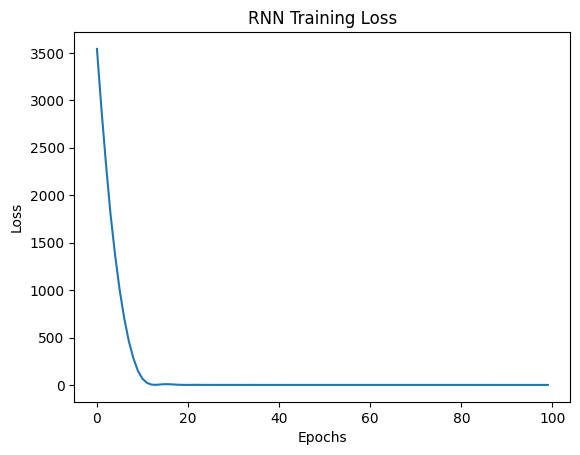

In [8]:
plt.plot(history.history['loss'])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("RNN Training Loss")
plt.show()

In [9]:
# Test with new sequence
test_input = np.array([[101, 102, 103]])
test_input = test_input.reshape((1,3,1))

prediction = model.predict(test_input)

print("Input Sequence:", test_input.flatten())
print("Predicted Output:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
Input Sequence: [101 102 103]
Predicted Output: 104.70374
